# Reading GHCN observations

This notebook introduces how to use the `hydropandas` package to read, process
and visualise data from the Global Historical Climatology Network (GHCN).
GHCN-Daily is a database of daily climate summaries from land surface stations
around the world, maintained by NOAA.

In [27]:
import contextily as ctx
import matplotlib.pyplot as plt

import hydropandas as hpd
from hydropandas.io import ghcn

# enabling logging so we can see what happens in the background
hpd.util.get_color_logger("INFO");

## Read GHCN observations within an extent

Use `hpd.read_ghcn` to download all GHCN stations within a bounding box.
The `extent` parameter is `[xmin, xmax, ymin, ymax]` in the coordinate system
given by `epsg`. Setting `elements='PRCP'` downloads only precipitation data;
leave it as `None` to retrieve all available elements.

In [28]:
# read GHCN precipitation observations for an area in the Netherlands
# extent: [xmin, xmax, ymin, ymax] in RD New (EPSG:28992)
extent = [120_000, 140_000, 450_000, 470_000]

oc = hpd.read_ghcn(
    extent=extent,
    epsg=28992,
    elements="PRCP",
    tmin="2020-01-01",
    tmax="2021-12-31",
)
oc

INFO:hydropandas.io.ghcn.get_obs_list_from_extent:downloading GHCN data from 2 stations


station: 100%|██████████| 2/2 [00:02<00:00,  1.23s/it]


,x,y,location,filename,source,unit,station,meteo_var,obs
name,,,,,,,,,
NLE00101997_PRCP,130800.683867,469904.652351,,,GHCN,m,NLE00101997,PRCP,MeteoObs NLE00101997_PRCP -----metadata------ ...
NLE00109338_PRCP,128459.366934,455051.983470,,,GHCN,m,NLE00109338,PRCP,MeteoObs NLE00109338_PRCP -----metadata------ ...


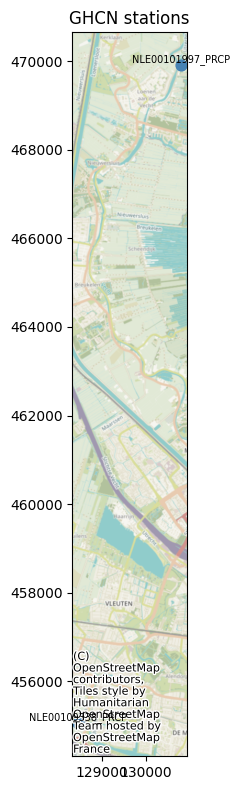

In [29]:
# plot station locations on a map
ax = oc.to_gdf(crs=28992).plot(figsize=(8, 8), color="steelblue", markersize=60)
ctx.add_basemap(ax=ax, crs=28992)

for idx, row in oc.iterrows():
    ax.annotate(text=idx, xy=(row["x"], row["y"]), fontsize=7, ha="center", va="bottom")
ax.set_title("GHCN stations")
plt.tight_layout()

## Plot observations from a single station

Station: NLE00101997_PRCP  |  element: PRCP  |  unit: m


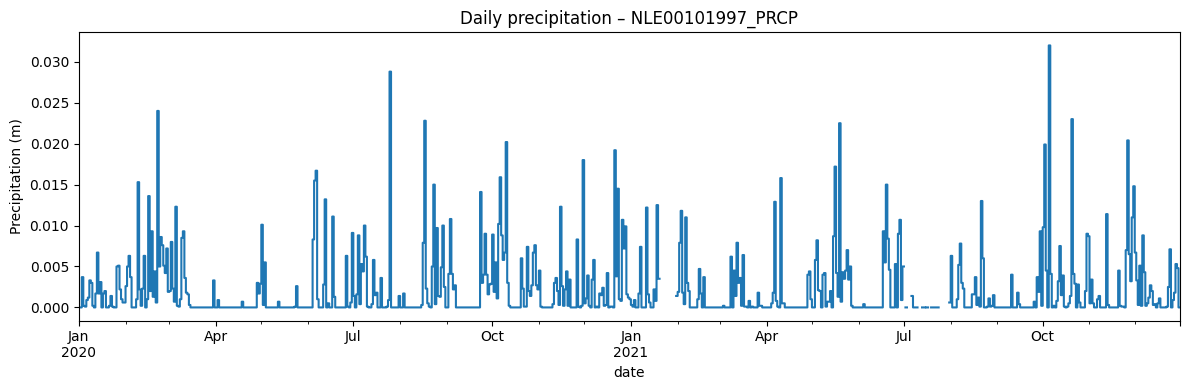

In [30]:
# select the first observation and plot the precipitation time series
o = oc.iloc[0].obs
print(f"Station: {o.name}  |  element: PRCP  |  unit: {o.unit}")
o["PRCP"].plot(
    figsize=(12, 4),
    drawstyle="steps",
    ylabel="Precipitation (m)",
    title=f"Daily precipitation – {o.name}",
)
plt.tight_layout()

## Download multiple elements (temperature)

Omit the `elements` argument (or pass a list) to download all available
elements for the stations in the extent. Here we request maximum and minimum
daily temperature (`TMAX` and `TMIN`) for a small extent around De Bilt.

In [31]:
# read TMAX and TMIN for De Bilt area
extent_debilt = [4.9, 5.2, 51.9, 52.1]  # [xmin, xmax, ymin, ymax] WGS84

oc_temp = hpd.read_ghcn(
    extent=extent_debilt,
    epsg=4326,
    elements=["TMAX", "TMIN"],
    tmin="2020-01-01",
    tmax="2020-12-31",
)
oc_temp

INFO:hydropandas.io.ghcn.get_obs_list_from_extent:downloading GHCN data from 4 stations


station: 100%|██████████| 4/4 [00:05<00:00,  1.28s/it]


,x,y,location,filename,source,unit,station,meteo_var,obs
name,,,,,,,,,
NLE00108992,4.9331,52.0000,,,GHCN,,NLE00108992,,MeteoObs NLE00108992 -----metadata------ name ...
NLE00109338,5.0000,52.0831,,,GHCN,,NLE00109338,,MeteoObs NLE00109338 -----metadata------ name ...
NLE00152476_TMAX,4.9256,51.9692,,,GHCN,unknown,NLE00152476,TMAX,MeteoObs NLE00152476_TMAX -----metadata------ ...
NLE00152476_TMIN,4.9256,51.9692,,,GHCN,unknown,NLE00152476,TMIN,MeteoObs NLE00152476_TMIN -----metadata------ ...
NLM00006260_TMAX,5.1794,52.0989,,,GHCN,unknown,NLM00006260,TMAX,MeteoObs NLM00006260_TMAX -----metadata------ ...
NLM00006260_TMIN,5.1794,52.0989,,,GHCN,unknown,NLM00006260,TMIN,MeteoObs NLM00006260_TMIN -----metadata------ ...


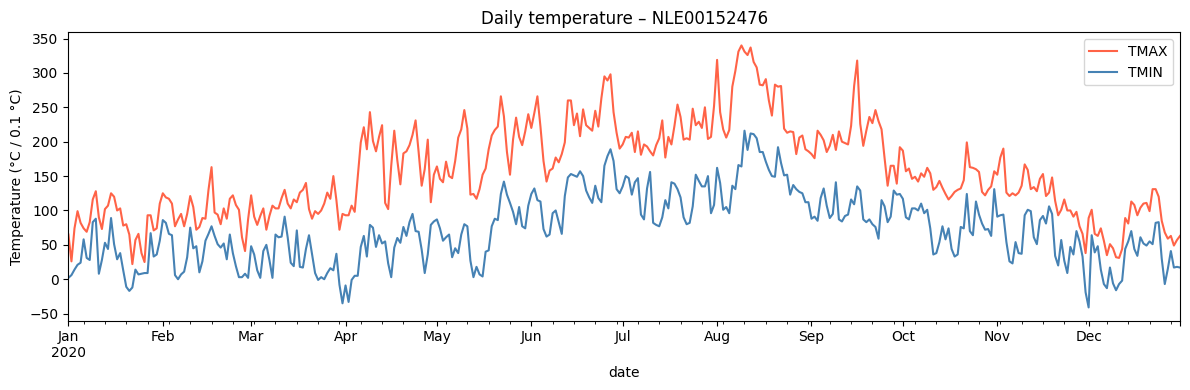

In [32]:
# plot temperature observations for the first station
temp_min = oc_temp.get_obs(meteo_var="TMIN", station="NLE00152476")
temp_max = oc_temp.get_obs(meteo_var="TMAX", station="NLE00152476")
f, ax = plt.subplots(figsize=(12, 4))
temp_max["TMAX"].plot(ax=ax, label="TMAX", color="tomato")
temp_min["TMIN"].plot(ax=ax, label="TMIN", color="steelblue")
ax.set_ylabel("Temperature (°C / 0.1 °C)")
ax.set_title(f"Daily temperature – {temp_min.station}")
ax.legend()
f.tight_layout()

## Explore available stations

Use `ghcn.get_stations` to retrieve a GeoDataFrame with all GHCN stations
worldwide or filtered to an extent, without downloading any measurements.

In [33]:
oc_meta

,x,y,location,filename,source,unit,station,meteo_var,obs
name,,,,,,,,,
NLE00108992,4.9331,52.0000,,,GHCN,,NLE00108992,,MeteoObs NLE00108992 -----metadata------ name ...
NLE00109338,5.0000,52.0831,,,GHCN,,NLE00109338,,MeteoObs NLE00109338 -----metadata------ name ...
NLE00152476,4.9256,51.9692,,,GHCN,,NLE00152476,,MeteoObs NLE00152476 -----metadata------ name ...
NLM00006260,5.1794,52.0989,,,GHCN,,NLM00006260,,MeteoObs NLM00006260 -----metadata------ name ...


In [34]:
# get station metadata only (fast – no measurements downloaded)
oc_meta = hpd.read_ghcn(
    extent=extent_debilt,
    epsg=4326,
    only_metadata=True,
)
print(f"Found {len(oc_meta)} stations in the extent")
oc_meta[["x", "y", "source", "station"]]

INFO:hydropandas.io.ghcn.get_obs_list_from_extent:downloading GHCN data from 4 stations


station: 100%|██████████| 4/4 [00:00<00:00, 2946.47it/s]

Found 4 stations in the extent


,x,y,source,station
name,,,,
NLE00108992,4.9331,52.0000,GHCN,NLE00108992
NLE00109338,5.0000,52.0831,GHCN,NLE00109338
NLE00152476,4.9256,51.9692,GHCN,NLE00152476
NLM00006260,5.1794,52.0989,GHCN,NLM00006260


In [42]:
# interactive map of all downloaded observations
m = oc.plots.interactive_map(tmin="2020", tmax="2021")
m.save("test.html")

ERROR:hydropandas.extensions.plots.interactive_plots:NLE00101997_PRCP has no data between 2020 and 2021


ERROR:hydropandas.extensions.plots.interactive_plots:NLE00109338_PRCP has no data between 2020 and 2021
INFO:hydropandas.extensions.plots.interactive_map:no iplot available for NLE00109338_PRCP
